In [1]:
# Put import statements here
import sys
import subprocess
from pathlib import Path

# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.util.logger import Logger
from src.data_preprocessing.TextTokenizer import TextTokenizer


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# Run pytest setup tests to verify the environment/hardware is good to go
#subprocess.run(
#    [sys.executable, "-m", "pytest", "-q", "test/test_setup.py"],
#    check=False,
#)

In [3]:
# Determine the project root's location, that way file paths will be more consistent
PROJECT_ROOT= Path.cwd()
DATA_DIR= PROJECT_ROOT / "data"

Logger.info(f"Project root absolute path: {PROJECT_ROOT}")

20:46:13 [INFO    ]: Project root absolute path: /home/chris/capstone/PlantQA


In [4]:
# load the plantExpertVQA training, validation, and testing datasets
plant_expert_vqa_data_path= DATA_DIR / "PlantExpertVQA" / "data"
train_data_path= plant_expert_vqa_data_path / "train.csv" 
test_data_path= plant_expert_vqa_data_path / "test.csv" 
validation_data_path= plant_expert_vqa_data_path / "val.csv" 


plant_expert_vqa_TRAIN= text_pre.load_csv(train_data_path)
plant_expert_vqa_TEST= text_pre.load_csv(test_data_path)
plant_expert_vqa_VAL= text_pre.load_csv(validation_data_path)

20:46:15 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/train.csv into dataframe


/home/chris/capstone/PlantQA/src/data_preprocessing/text_preprocessing.py:27: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


20:46:16 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe
20:46:16 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/val.csv into dataframe


In [5]:
# Clean and normalize the data (does not tokenize here)

# There are a pretty large number of NA values in the dataset (mostly question_category)
# Instead of removing those entirely and hugely shrinking our dataset, fill them with generic values
# This list is pairs of (column name, value to replace NA values with)
column_fill_pairs= [
    ("answer_type", "unspecified"),
    ("question_text", ""),
    ("question_category", "unspecified"),
    ("cognitive_level", "unspecified"),
]
# text columns to normalize
columns_to_preprocess= ["question_text", "answer"]
# unwanted columns
columns_to_remove= ["dataset_source"]

# preprocess (not tokenize) the training, testing, and validation datasets
# NOTE: the stop word removal may be too intense.  We most likely want to fine tune the stopword set, or define our own set
#       Right now it removes words like "what" and "why", which will most likely be bad for a VQA system that answers questions.

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    columns_to_preprocess,
    columns_to_remove,
    column_fill_pairs
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    columns_to_preprocess,
    columns_to_remove,
    column_fill_pairs
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    columns_to_preprocess,
    columns_to_remove,
    column_fill_pairs
)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535881 entries, 0 to 535880
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   qa_id              535881 non-null  object
 1   image_id           535881 non-null  object
 2   image_path         535881 non-null  object
 3   crop               535881 non-null  object
 4   disease            535881 non-null  object
 5   category           535881 non-null  object
 6   severity           535881 non-null  object
 7   question_text      535881 non-null  object
 8   answer             535881 non-null  object
 9   answer_type        535881 non-null  object
 10  question_category  535881 non-null  object
 11  cognitive_level    535881 non-null  object
dtypes: object(12)
memory usage: 49.1+ MB
20:46:26 [INFO    ]: Plant Expert VQA Training Dataset Info:
None



20:46:27 [INFO    ]: Plant Expert VQA Training Dataset Description:
                                      

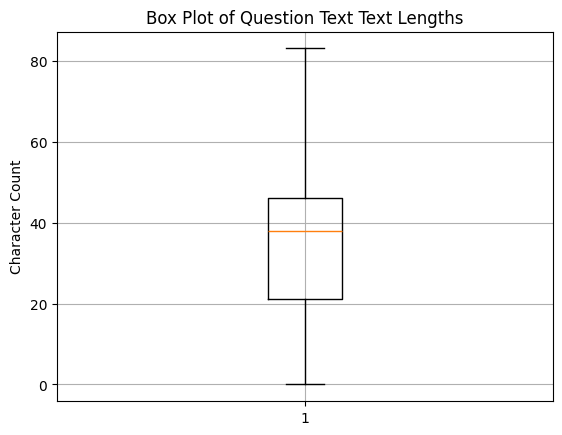

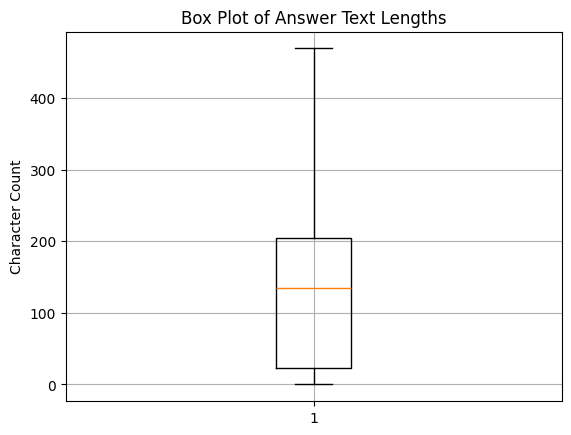







20:46:27 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Class Frequency Distributions --------




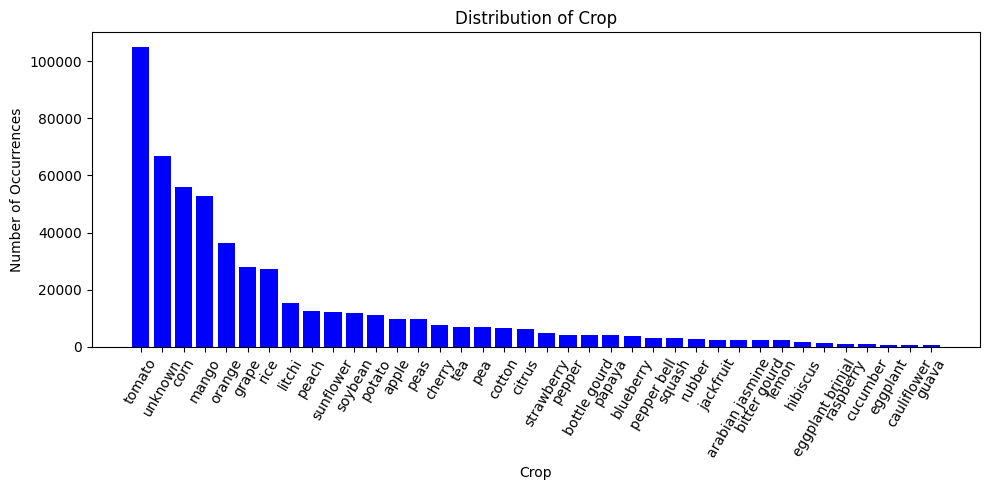

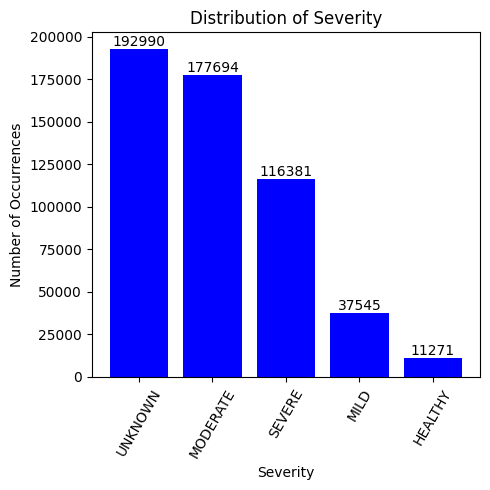

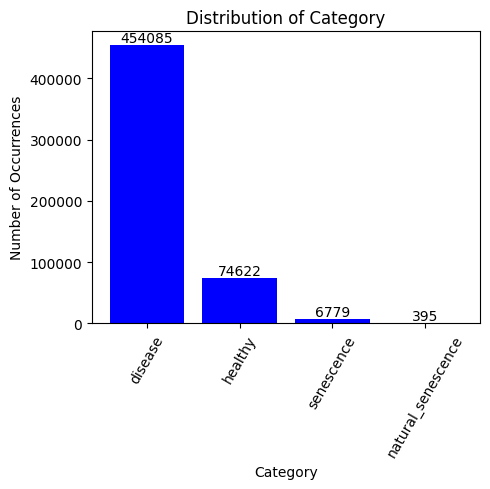

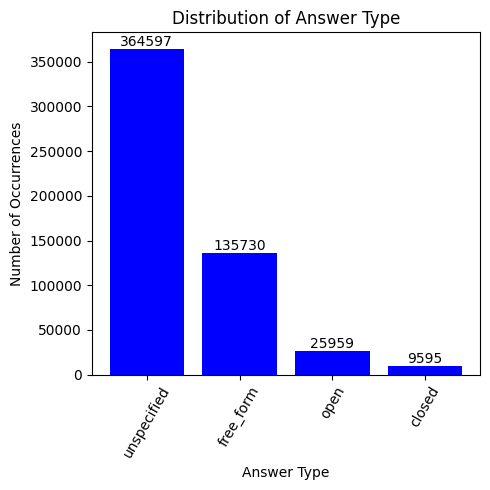

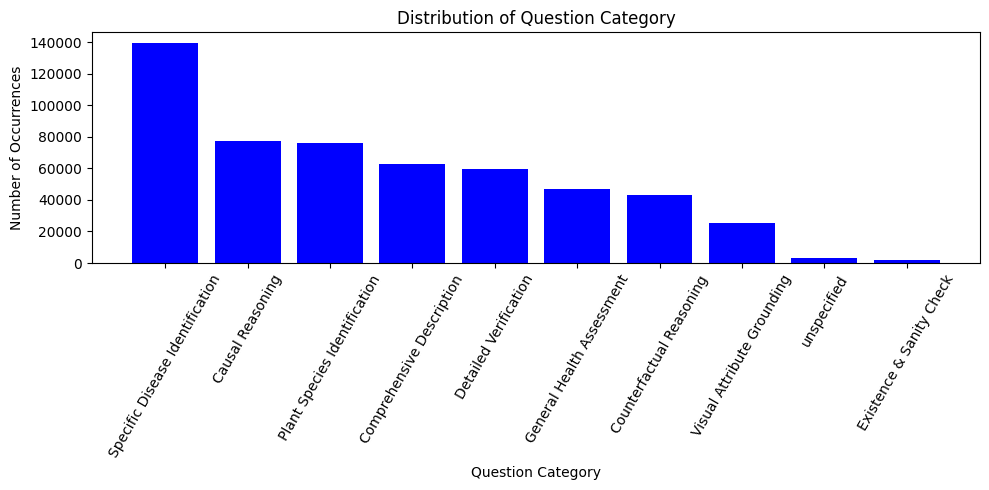







20:46:28 [INFO    ]: 

-------- Plant Expert VQA Training Dataset WordClouds --------




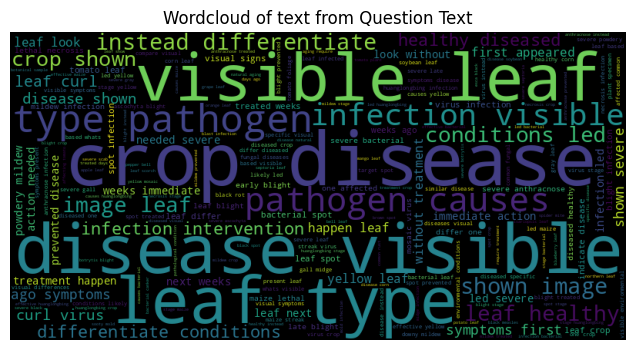

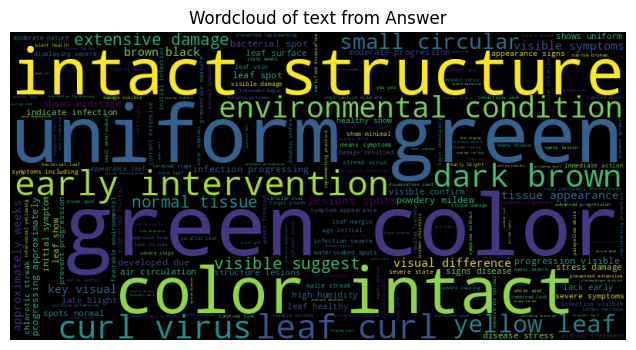







20:46:41 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Word Frequency Distributions --------




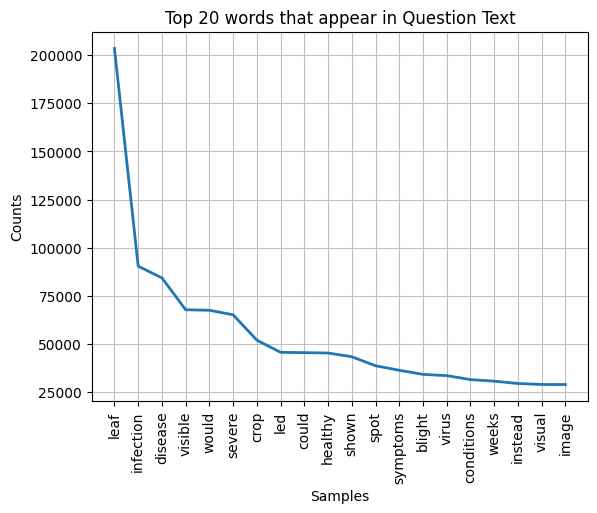

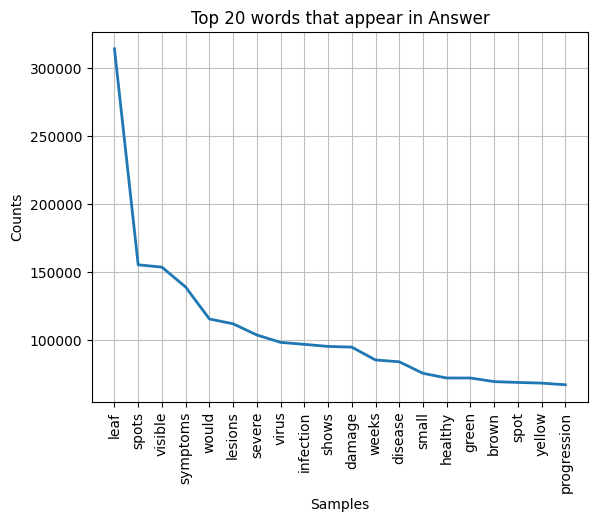

In [6]:
 

column_distribution_args= [
    {"column": "crop", "show_counts": False, "figure_size": (10, 5)},
    {"column": "severity", "show_counts": True, "figure_size": (5, 5)},
    {"column": "category", "show_counts": True, "figure_size": (5, 5)},
    {"column": "answer_type", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_category", "show_counts": False, "figure_size": (10, 5)},
]

text_columns= ["question_text", "answer"]

# explore the cleaned training dataset
text_explore.explore_data(
    plant_expert_vqa_TRAIN, 
    column_distribution_args, 
    text_columns, 
    top_n_words=20, 
    name="Plant Expert VQA Training Dataset"
)

In [7]:
tokenizer= TextTokenizer("distilbert-base-uncased", 128)

encoding= tokenizer.encode_text("hello", None)

Logger.info(encoding)

20:46:45 [INFO    ]: {'input_ids': [[101, 7592, 102]], 'token_type_ids': [[0, 0, 0]], 'attention_mask': [[1, 1, 1]]}
